<a href="https://colab.research.google.com/github/majumdarmanjari14-commits/PCB-defect-detector/blob/main/01_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['pcb-defect-detection']


In [ ]:
#THIS IS USED TO TEST THAT THE GPU HAS BEEN CONNECTED OR NOT
import torch #loads PyTorch- the library i will be using.
print(torch.cuda.is_available()) #CUDA lets the python talk to a GPU
print(torch.cuda.get_device_name(0)) #if GPU exists it lets it print its name like Tesla T4

True
Tesla T4


In [ ]:
#this tells where your project lives on the drive.
#RUN THIS ONCE AT THE START OF EVERY SESSION
import os

# Your project root on Google Drive
PROJECT = '/content/drive/MyDrive/pcb-defect-detection'

# All the subfolders
DATA_DIR   = os.path.join(PROJECT, 'data')
MODELS_DIR = os.path.join(PROJECT, 'models')
LOGS_DIR   = os.path.join(PROJECT, 'logs')

# Create them if they don't exist yet
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(LOGS_DIR,   exist_ok=True)

print("Project path:", PROJECT)
print("Folders ready.")

Project path: /content/drive/MyDrive/pcb-defect-detection
Folders ready.


In [ ]:
!pip install timm grad-cam -q # -q means quiet it will not flood the screen with unnecessary o/p
# timm is the pytorch image model that feeds pretrained image models
# grad cam is gradient weighted class activation mapping
#grad cam is used to tell why the defect has been detected or which part of the image made the network predict the class


In [ ]:
#this is for checking whether all tbhe libraries has been downloaded.
import torch
import torchvision
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print(f"PyTorch:     {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"timm:        {timm.__version__}")
print("All packages ready.")

PyTorch:     2.11.0+cu128
Torchvision: 0.26.0+cu128
timm:        1.0.27
All packages ready.


In [ ]:
import os

dataset_path = os.path.join(DATA_DIR, 'DeepPCB')

# Only download if not already there
if not os.path.exists(dataset_path):
    print("Downloading DeepPCB dataset...")
    os.makedirs(dataset_path, exist_ok=True)

    # Clone from GitHub
    !git clone https://github.com/tangsanli5201/DeepPCB.git {dataset_path}
    print("Download complete.")
else:
    print("Dataset already exists. Skipping download.")

# Verify
contents = os.listdir(dataset_path)
print(f"Dataset folder contents: {contents}")

Dataset already exists. Skipping download.
Dataset folder contents: ['tools', '.git', 'fig', 'evaluation', '.gitignore', 'LICENSE', 'PCBData', 'README.md']


In [ ]:
import os

pcb_data_path = os.path.join(DATA_DIR, 'DeepPCB', 'PCBData')

# Count board folders
board_folders = [f for f in os.listdir(pcb_data_path)
                 if os.path.isdir(os.path.join(pcb_data_path, f))]

print(f"Total board folders: {len(board_folders)}")
print(f"First 5 folder names: {board_folders[:5]}")

# Look inside one folder to understand structure
sample_folder = os.path.join(pcb_data_path, board_folders[0])
sample_contents = os.listdir(sample_folder)
print(f"\nInside folder '{board_folders[0]}':")
for item in sample_contents:
    print(f"  {item}")

Total board folders: 11
First 5 folder names: ['group13000', 'group50600', 'group12000', 'group12100', 'group20085']

Inside folder 'group13000':
  13000_not
  13000


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

pcb_data_path = os.path.join(DATA_DIR, 'DeepPCB', 'PCBData')
board_folders = sorted(os.listdir(pcb_data_path))

# Go into first board folder
sample_board = os.path.join(pcb_data_path, board_folders[0])
board_id = board_folders[0].replace('group', '')

# Get template and test image folders
template_folder = os.path.join(sample_board, board_id)
defective_folder = os.path.join(sample_board, f'{board_id}_not')

# Get first IMAGE file only (ignore .txt files)
template_img = [os.path.join(template_folder, f)
                for f in os.listdir(template_folder)
                if f.endswith('.jpg')][0]

defective_img = [os.path.join(defective_folder, f)
                 for f in os.listdir(defective_folder)
                 if f.endswith('.jpg')][0]

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(mpimg.imread(template_img))
axes[0].set_title('Template (defect-free)')
axes[0].axis('off')
axes[1].imshow(mpimg.imread(defective_img))
axes[1].set_title('Test image (defective)')
axes[1].axis('off')

plt.suptitle(f'Board: {board_folders[0]}', fontsize=13)
plt.tight_layout()
plt.show()

IndexError: list index out of range

In [ ]:
import os

pcb_data_path = os.path.join(DATA_DIR, 'DeepPCB', 'PCBData')
board_folders = sorted(os.listdir(pcb_data_path))

sample_board = os.path.join(pcb_data_path, board_folders[0])
board_id = board_folders[0].replace('group', '')

defective_folder = os.path.join(sample_board, f'{board_id}_not')

print("Files in defective folder:")
for f in os.listdir(defective_folder):
    print(f)

Files in defective folder:
00041061.txt
00041130.txt
00041215.txt
00041220.txt
00041214.txt
00041036.txt
00041171.txt
00041193.txt
00041070.txt
00041114.txt
00041092.txt
00041003.txt
00041052.txt
00041025.txt
00041045.txt
00041189.txt
00041098.txt
00041162.txt
00041186.txt
00041217.txt
00041155.txt
00041099.txt
00041132.txt
00041082.txt
00041009.txt
00041046.txt
00041178.txt
00041037.txt
00041081.txt
00041133.txt
00041173.txt
00041079.txt
00041191.txt
00041026.txt
00041097.txt
00041053.txt
00041164.txt
00041056.txt
00041187.txt
00041128.txt
00041145.txt
00041095.txt
00041165.txt
00041203.txt
00041089.txt
00041116.txt
00041156.txt
00041076.txt
00041119.txt
00041023.txt
00041147.txt
00041057.txt
00041058.txt
00041077.txt
00041120.txt
00041218.txt
00041185.txt
00041143.txt
00041123.txt
00041005.txt
00041160.txt
00041122.txt
00041027.txt
00041161.txt
00041204.txt
00041075.txt
00041126.txt
00041024.txt
00041096.txt
00041201.txt
00041105.txt
00041195.txt
00041000.txt
00041183.txt
00041007.tx

In [ ]:
import os

pcb_data_path = os.path.join(DATA_DIR, 'DeepPCB', 'PCBData')
board_folders = sorted(os.listdir(pcb_data_path))

sample_board = os.path.join(pcb_data_path, board_folders[0])
board_id = board_folders[0].replace('group', '')

template_folder = os.path.join(sample_board, board_id)

print("Files in template folder:")
for f in os.listdir(template_folder):
    print(f)

Files in template folder:
00041195_test.jpg
00041192_test.jpg
00041083_test.jpg
00041032_test.jpg
00041181_test.jpg
00041140_temp.jpg
00041068_temp.jpg
00041136_temp.jpg
00041115_temp.jpg
00041118_test.jpg
00041146_test.jpg
00041021_temp.jpg
00041173_test.jpg
00041129_test.jpg
00041074_test.jpg
00041056_test.jpg
00041013_temp.jpg
00041105_temp.jpg
00041101_temp.jpg
00041170_test.jpg
00041155_test.jpg
00041196_test.jpg
00041062_temp.jpg
00041203_test.jpg
00041062_test.jpg
00041071_temp.jpg
00041127_temp.jpg
00041054_temp.jpg
00041200_temp.jpg
00041216_temp.jpg
00041094_temp.jpg
00041173_temp.jpg
00041019_temp.jpg
00041086_test.jpg
00041035_temp.jpg
00041018_test.jpg
00041152_test.jpg
00041146_temp.jpg
00041096_test.jpg
00041186_temp.jpg
00041183_temp.jpg
00041153_test.jpg
00041040_temp.jpg
00041016_test.jpg
00041081_test.jpg
00041177_test.jpg
00041092_test.jpg
00041160_test.jpg
00041004_test.jpg
00041019_test.jpg
00041026_temp.jpg
00041058_test.jpg
00041131_test.jpg
00041149_test.jpg
00

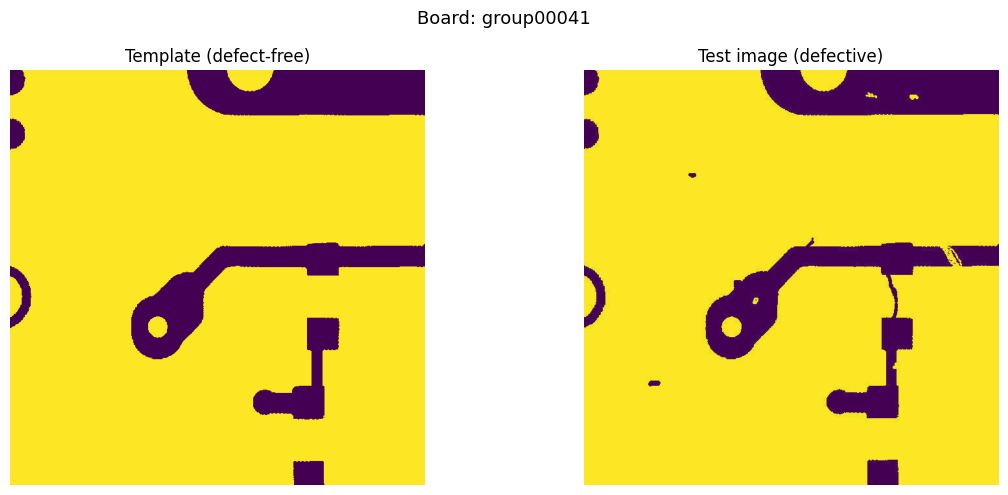

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

pcb_data_path = os.path.join(DATA_DIR, 'DeepPCB', 'PCBData')
board_folders = sorted(os.listdir(pcb_data_path))

sample_board = os.path.join(pcb_data_path, board_folders[0])
board_id = board_folders[0].replace('group', '')
image_folder = os.path.join(sample_board, board_id)

# Get one temp and its matching test image
all_files = os.listdir(image_folder)
temp_files = sorted([f for f in all_files if f.endswith('_temp.jpg')])

# Pick first pair
first_temp = temp_files[0]
first_test = first_temp.replace('_temp.jpg', '_test.jpg')

temp_path = os.path.join(image_folder, first_temp)
test_path = os.path.join(image_folder, first_test)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(mpimg.imread(temp_path))
axes[0].set_title('Template (defect-free)')
axes[0].axis('off')
axes[1].imshow(mpimg.imread(test_path))
axes[1].set_title('Test image (defective)')
axes[1].axis('off')

plt.suptitle(f'Board: {board_folders[0]}', fontsize=13)
plt.tight_layout()
plt.show()
